In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_excel(r'E:\AI Projects\ML Course\Regression\Reg_Files\salary.xlsx')
x = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

Feature scaling is consider in SVR for salary data set because the difference between level and salary
affect the model, maybe neglect the level column
also dummy variables, dependent variables with binary values (0,1) we don't need feature scaling
if we split our data set into train and test, feature scaling apply after spliting 

In [3]:
# as we need to standrdaize the dataset, we need to reshape the y
y = y.reshape(len(y), 1)

In [4]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
x = sc_x.fit_transform(x)
y = sc_y.fit_transform(y)

Set of mathematic functions are defined as the kernel, take data as input and transform it into the requiered form. we use RBF(Gaussian radial basis function). used when there is no general knowledge about the data.
"data-flair.training.blogs -> visit"

In [5]:
from sklearn.svm import SVR
regressor = SVR(kernel= 'rbf')
regressor.fit(x, y)

C:\Users\babaei.nima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


because both (x,y) are scaled to predict we must use reverse scaling method

In [ ]:
sc_y.inverse_transform(regressor.predict(sc_x.transform([[11]])).reshape(-1, 1))

In [7]:
print(sc_x.inverse_transform(x))
print(sc_y.inverse_transform(y))

[[ 1.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 7.]
 [ 8.]
 [ 9.]
 [10.]
 [11.]
 [12.]
 [13.]
 [14.]
 [15.]
 [16.]
 [17.]
 [18.]
 [19.]]
[[5.090760e+08]
 [5.093210e+08]
 [5.532610e+08]
 [5.617580e+08]
 [5.690030e+08]
 [5.764290e+08]
 [5.842270e+08]
 [6.047510e+08]
 [6.295410e+08]
 [6.319950e+08]
 [6.561530e+08]
 [6.645210e+08]
 [6.813430e+08]
 [7.010700e+08]
 [7.189100e+08]
 [7.532680e+08]
 [8.853230e+08]
 [9.900540e+08]
 [1.537106e+09]]


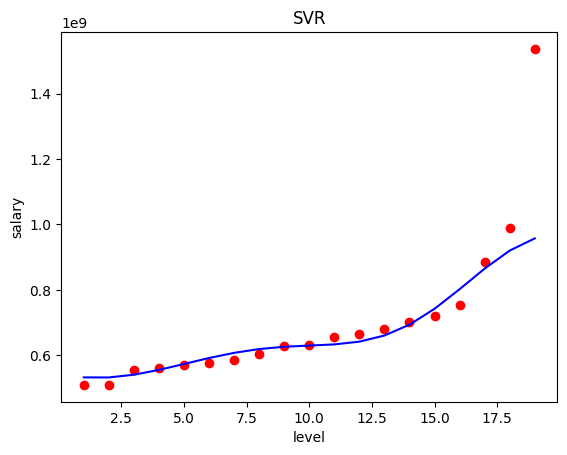

In [6]:
plt.scatter(sc_x.inverse_transform(x) ,sc_y.inverse_transform(y) , color = 'red')
plt.plot(sc_x.inverse_transform(x) , 
         sc_y.inverse_transform(regressor.predict(x).reshape(-1, 1)), color = 'blue')
plt.title('SVR')
plt.xlabel('level')
plt.ylabel('salary')
plt.show()